# تحويلات الصورة في OpenCV:
## تحويل فورييه:

## الهدف:
** في هذا الفصل سنتعلم:**

* ايجاد تحويل فورييه للصور باستخدام OpenCV

* استخدام توابع الFFT المتوفرة في Numpy.

* بعض تطبيقات تحويل فورييه.

* وسنرى التوابع التالية: **cv2.dft , cv2.idft** الخ.


## النظرية:
يستخدم تحويل فورييه لايجاد المجال الترددي للمرشحات , وكذلك تحويل فورريه المتقطع DFT  للصور لنقلها للمجال الترددي , ولكن يتم تطبيقه عبر خوارزمية FFT,

مثلاً , لاشارة ,$$x(t)=A sin(2\pi ft)$$  يمكننا القول ان *f* هو تردد الاشارة , وعند التحويل للمجال الترددي نرى نبضة في موضعها .
واذا اعتبرنا الصورة نبضة ذات بعدين , فانه عند تحويلها للمجال الترددي نحصل على تمثيل آخر لها.

وحدسياً , اذا لاحظنا موجة سريعة التغير فسيكون محتواها الترددي مرتفعاً والا سيكون منخفضاً , اذا كانت بطيئة التغير , وهذا ايضاً ينطبق على الصور , فالصور ذات المحتوى المرتفع  التغير , كالحواف او الضجيج تشكل ترددات عالية , والا منخفضة ..

الان لنرى كيفية حساب تحويل فورييه.

## تحويل فورييه في Numpy:
اولا التابع المسؤول عن تحويل فورييه هو : **np.fft.fft2** الذي يعطينا التحويل الترددي كمصفوفة عقدية . ودخله الاول هو صورة الدخل ,و دخله الثاني كيفي وهو حجم الخرج , حيث يتم اما تمديد الصورة باصفار أو قص الصورة , حسب الحجم , المرغوب ,والا يؤخذ نفس حجم الصورة في الدخل , 

وبعد ان تحصل على النتيجة , فان التردد الصفري للمركبة الثابتة سيتموضع في الزاوية العليا اليسرى , ولذلك نحتاج لازاحته للمركز وذلك بازاحته بمسافة $\frac N2$ في كلا الاتجاهين . وذلك عبر التابع **np.fft.fftshift** لسهولة التحليل , وبعد ذلك يجب علينا ايجاد طويلة الطيف كالتالي

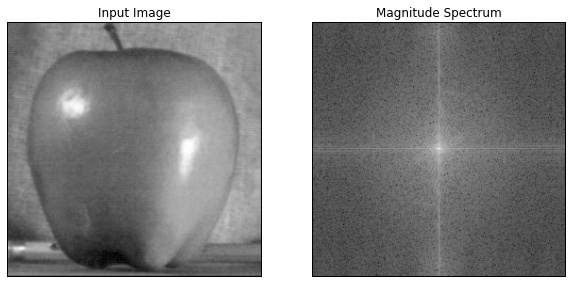

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

img = cv2.imread('apple.png',0)
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20*np.log(np.abs(fshift))

plt.figure(figsize = (10,5))
plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

والمحتوى الابيض بالقرب من المركز يبين ان الترددات المنخفضة هي السائدة. 

وبعد ايجاد التردد يمكنك القيام بعدة عمليات مثل اخذ التردد و الضرب بقناع كمرشح الترددات العالية , ويتم ذلك ببساطة بضرب الناتج بمستطيل في المركز يقياسات مناسبة , وبعدها تطبيق الازاحة العكسية **np.fft.ifftshift** حيث تعود الصورة لمكانها , وبعدها نطبق تحويل فورييه العكسي , **np.ifft2** . والنتيجة ستكون ايضاً عدداً عقدياً , حيث يمكننا اخذ القيم المطلقة منه.

راقب الكود التالي:

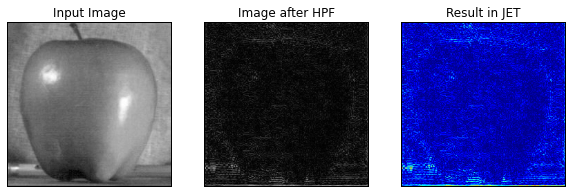

In [3]:
rows, cols = img.shape
crow,ccol = rows/2 , cols/2

# حذفنا الترددات المنخفضة
fshift[crow-30:crow+30, ccol-30:ccol+30] = 0

f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

plt.figure(figsize=(10,5))
plt.subplot(131),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(img_back, cmap = 'gray')
plt.title('Image after HPF'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(img_back)
plt.title('Result in JET'), plt.xticks([]), plt.yticks([])

plt.show()

نلاحظ نظرياً , وكأنه تم اشتقاق الحواف من الصورة , بسبب المرشح ذو التمرير العالي , وهذا تم من خلال Numpy  اما فيما يلي فسنقوم بنفس الشيء انما في OpenCV.

واذا لا حظت بالصور الناتجة , هناك عدا الحواف نقاط  ضجيج اخرى , وذلك بسبب تأثير النافذة المربعة , والذي يدعى تأثير الاهتزاز **ringing_effect** وهذا يتم تجاوزه باستخدام اشكال اخرى للمرشحات كالغاوسي.


## تحويل فورييه في OpenCV:
openCV يقدم التابعين **cv2.dft , cv2.idft ** لهذا ويعيد نفس السابق انما بقناتين كل منهما تمثل القسم الحقيقي والتخيلي , كل على حدا, وصورة الدخل يجب ان تكون بالصيغة **np.float32 ** 


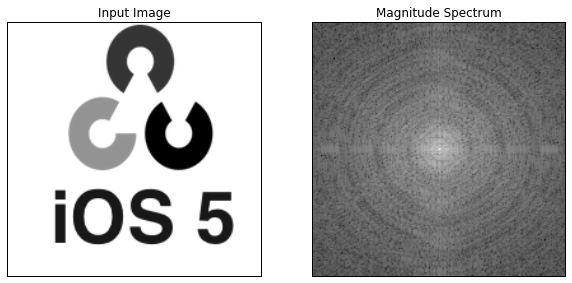

In [5]:

img = cv2.imread('opencv_ios.png',0) 

dft = cv2.dft(np.float32(img),flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

magnitude_spectrum = 20*np.log(cv2.magnitude(
        dft_shift[:,:,0],dft_shift[:,:,1]))

plt.figure(figsize=(10,5))
plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

### ملاحظة : 
يمكنك استخدام **cv2.cartToPolar** والذي يعيد كل من الطويلة والزاوية معاً..

والان سنرى التحويل العكسي , وبما انه تم سابقاً , اظهار المرشح ذو التردادات المرتفعة , نقوم الان بانشاء مرشح لتمرير التردادات المنخفضة (تغبيش الصورة)بجعله يمرر الترددات بالوسط كالتالي:


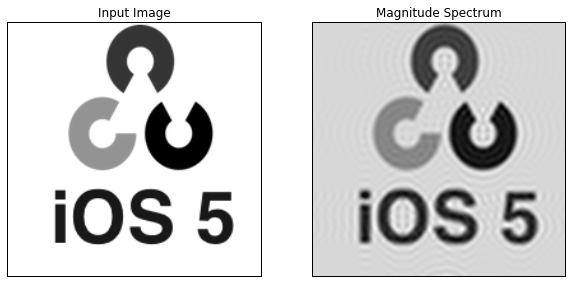

In [6]:
rows, cols = img.shape
crow,ccol = rows/2 , cols/2

# create a mask first, center square is 1, remaining all zeros
mask = np.zeros((rows,cols,2),np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 1

# apply mask and inverse DFT
fshift = dft_shift*mask
f_ishift = np.fft.ifftshift(fshift)
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])

plt.figure(figsize=(10,5))
plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(img_back, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

** ملاحظة:** كالعادة , فتوابع OpenCV اسرع من نظرائهم في Numpy  ولكن الاخيرة اكثر مقروئية.

في الفقرة الاخيرة سوف نبحث سؤالاً اضافياً

## لماذا القناع اللابلاسي هو مرشح ترددات عالية؟
هذا السؤال تم طرحه مسبقاً وايضا لماذا Sobel هو HPF ? الاجابة كانت بدلالة تحويل فورييه , بما ان القناع في المجال الزمني فتحويله للمجال الترددي سيوضح سلوكه , كالتالي:

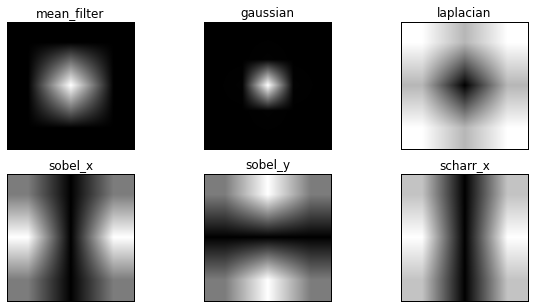

In [8]:
# simple averaging filter without scaling parameter
mean_filter = np.ones((3,3))

# creating a guassian filter
x = cv2.getGaussianKernel(5,10)
gaussian = x * x.T

# different edge detecting filters
# scharr in x-direction
scharr = np.array([[-3, 0, 3],
                   [-10,0,10],
                   [-3, 0, 3]])

# sobel in x direction
sobel_x= np.array([ [-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

# sobel in y direction
sobel_y= np.array([ [-1,-2,-1],
                    [0, 0, 0],
                    [1, 2, 1]])

#laplacian
laplacian=np.array([[0, 1, 0],
                    [1,-4, 1],
                    [0, 1, 0]])

filters = [mean_filter, gaussian, laplacian, sobel_x,
           sobel_y, scharr]
filter_name = ['mean_filter', 
               'gaussian','laplacian',
               'sobel_x', \
                'sobel_y', 'scharr_x']

fft_filters = [np.fft.fft2(x) for x in filters]
fft_shift = [np.fft.fftshift(y) for y in fft_filters]
mag_spectrum = [np.log(np.abs(z)+1) for z in fft_shift]

plt.figure(figsize=(10,5))
for i in xrange(6):
    plt.subplot(2,3,i+1),plt.imshow(mag_spectrum[i],cmap = 'gray')
    plt.title(filter_name[i]), plt.xticks([]), plt.yticks([])
    
plt.show()

من الصور الناتجة , يمكننا بوضوح تقرير ما اذا كان المرشح , ممررا للتردادات المنخفضة ام العالية بوضوح..

## مراجع اضافية :

1. شرح بدائي لنظرية فورييه , Steven Lehar

2. تحويل فورييه , HIPR

3. ماذا يعطي المجال الترددي بحالة الصور ؟

## تمارين ..